# Why $J$ did not accelerate — and the integrator that fixes it

Running the constrained-ball notebook at $\eta=5\times10^{-3}$, $R=1.5$, $\delta=0.2$ gives a result that
looks like a contradiction: adding the state-dependent skew $J_s$ makes things **worse**, not better.

```
ell   floor [0.0124 0.0127 0.0152]
      J = 0                          W1 [0.0185 0.0283 0.0238]   on-boundary 0.0774
      state-dependent J_s, s = 4.0   W1 [0.0185 0.0305 0.0334]   on-boundary 0.0804
```

Nothing is wrong with the theory. Two separate things are wrong with the *measurement* and the
*integrator*, and this notebook isolates both, then rebuilds the algorithm around them.

**Diagnosis 1 — the metric cannot show a gain.** Those numbers are `W1[-100:].mean()`, the error at
**stationarity**. $J_s$ leaves $\pi$ invariant by construction; it changes the rate, not the fixed point.
Comparing two schemes that have both already converged measures only their discretization bias, and $J_s$
can only *add* to that. A speed-up has to be read where the chain is still moving.

**Diagnosis 2 — at this $\eta$, Euler actively breaks the skew term.** $J_s(x)g=s\,(x\times g)$ is
tangential to the sphere through $x$, so the exact flow conserves $\lVert x\rVert$. The Euler step follows
the tangent **line** instead of the arc, inflating the radius by $O(\eta^2s^2)$ every step. At
$\eta=10^{-3}$ that is negligible; at $5\times10^{-3}$ it is 25 times larger and it dominates. Below,
Euler at $s=32$ puts **42.5%** of the ensemble on the boundary against a target value of 0.22%.

**The fix, in three parts.**

1. **Integrate the rotation exactly.** With $g=e^{\Delta}\nabla U_0$ frozen over a step, the skew ODE is
   $\dot x=\omega\times x$ with $\omega=s\,g$ — a rigid rotation. Its exact solution is Rodrigues'
   formula, which preserves $\lVert x\rVert$ to machine precision. Strang-split it around the reversible
   step and the skew term contributes **zero** boundary overshoot at any $s$.
2. **Reflect instead of project.** Projection places every escaping particle exactly on the sphere,
   creating an atom the target does not have (7.5% of mass here). Reflecting the excess radius back inside
   creates no atom.
3. **Anneal $s$.** The acceleration is only needed while the chain is travelling; any residual per-step
   cost is paid at whatever $s$ that step uses. $\nabla\!\cdot J_s=0$ and $J_s(x)\nu(x)=0$ hold for
   *every* $s$, so a schedule is a non-homogeneous chain each of whose steps preserves the same $\pi$.

Together these turn "$J$ makes it worse" into a **4–6× speed-up that also reaches an accuracy the original
scheme cannot reach at any iteration count**.

In [1]:
%matplotlib inline
import os
os.makedirs("figures", exist_ok=True)

import numpy as np
import torch
torch.set_default_dtype(torch.float64)
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy.stats import wasserstein_distance, ks_2samp

In [2]:
# -----------------------------
# Settings: exactly those of the uploaded notebook
# -----------------------------
d        = 3
R        = 1.5
N        = 5000
max_iter = 2000
eta      = 5e-3
delta    = 0.2
x_start  = 0.5
SEED     = 106
SEEDS    = [106, 11, 22, 33, 44]

SCALES, RHO = [0.5, 1.0, 2.0], 0.6
def make_L(dim, scales, rho):
    Dm = np.diag(scales); Cm = np.full((dim, dim), rho); np.fill_diagonal(Cm, 1.0)
    return np.linalg.cholesky(Dm @ Cm @ Dm)
L3 = make_L(d, SCALES, RHO)
Minv = torch.tensor(np.linalg.inv(L3))
print("Sigma =\n", np.round(L3 @ L3.T, 3))

Sigma =
 [[0.25 0.3  0.6 ]
 [0.3  1.   1.2 ]
 [0.6  1.2  4.  ]]


In [3]:
# -----------------------------
# Targets and exact reference sampler (unchanged from the original notebook)
# -----------------------------
def build_target(kind):
    if kind == "ell":
        @torch.no_grad()
        def U(x):  return torch.norm(x @ Minv.T, dim=1)
        @torch.no_grad()
        def U0(x): return torch.sqrt(torch.sum((x @ Minv.T) ** 2, dim=1) + delta ** 2)
        @torch.no_grad()
        def gU0(x):
            y = x @ Minv.T
            return (y / torch.sqrt(torch.sum(y ** 2, dim=1, keepdim=True) + delta ** 2)) @ Minv
    else:
        @torch.no_grad()
        def U(x):  return torch.sum(torch.abs(x @ Minv.T), dim=1)
        @torch.no_grad()
        def U0(x): return torch.sum(torch.sqrt((x @ Minv.T) ** 2 + delta ** 2), dim=1)
        @torch.no_grad()
        def gU0(x):
            y = x @ Minv.T
            return (y / torch.sqrt(y ** 2 + delta ** 2)) @ Minv
    return U, U0, gU0

def sample_target(kind, n, rng):
    out = []
    while len(out) < n:
        if kind == "ell":
            r = rng.gamma(d, 1.0, n)
            u = rng.normal(size=(n, d)); u /= np.linalg.norm(u, axis=1, keepdims=True)
            y = r[:, None] * u
        else:
            y = rng.laplace(0.0, 1.0, size=(n, d))
        z = y @ L3.T
        out.extend(z[np.linalg.norm(z, axis=1) <= R].tolist())
    return np.array(out[:n])

def on_boundary(X):
    return float(np.mean(np.linalg.norm(X, axis=1) > 0.999 * R))

## The two boundary rules, and the two integrators

`project` is the original rule: an escaping particle is placed on the sphere. `reflect` folds the excess
radius back inside, so no mass accumulates at $\lVert x\rVert=R$.

`euler` is the original integrator. `strang` splits the step as
$\tfrac12$ rotation $\to$ full anchored-Langevin step $\to$ $\tfrac12$ rotation, with each rotation applied
**exactly** by Rodrigues' formula

$$R(\omega)x=x\cos\theta+(\hat\omega\times x)\sin\theta+\hat\omega(\hat\omega\cdot x)(1-\cos\theta),
\qquad \theta=\lVert\omega\rVert,\ \ \omega=\eta\,s\,g .$$

At $s=0$ the two integrators are literally the same update, which is a useful control: every $J=0$ row
below must agree exactly between them.

In [4]:
@torch.no_grad()
def enforce(x, bc):
    nn = torch.norm(x, dim=1, keepdim=True)
    if bc == "project":
        return x * torch.clamp(R / nn, max=1.0)
    # radial reflection: radius r > R is folded to 2R - r.  No atom on the sphere.
    r_new = torch.where(nn > R, 2 * R - nn, nn).clamp(min=1e-12)
    return x * (r_new / nn)

@torch.no_grad()
def rodrigues(x, w):
    # rotate each row of x about axis w[i] by angle |w[i]| -- exact, preserves ||x||
    th = torch.norm(w, dim=1, keepdim=True)
    k = w / torch.clamp(th, min=1e-300)
    c, s = torch.cos(th), torch.sin(th)
    return x * c + torch.cross(k, x, dim=1) * s + k * (k * x).sum(1, keepdim=True) * (1 - c)

# --- the rotation is exact, to machine precision, at any angle
_x = torch.randn(2000, d) * 1.7
_w = torch.randn(2000, d) * 3.0
print("Rodrigues: max change in ||x|| = {:.2e}   (Euler tangent step would inflate it)".format(
    float((rodrigues(_x, _w).norm(dim=1) - _x.norm(dim=1)).abs().max())))
print("zero-angle branch is safe: max |R(0)x - x| = {:.2e}".format(
    float((rodrigues(_x, torch.zeros_like(_w)) - _x).abs().max())))
# how far off the sphere one *Euler* skew step lands, for a unit-radius point
for s_ in [4.0, 8.0, 16.0, 32.0]:
    xb = torch.randn(2000, d); xb = R * xb / xb.norm(dim=1, keepdim=True)
    gb = torch.randn(2000, d)
    step = xb - eta * s_ * torch.cross(xb, gb, dim=1)
    print("  s = {:<5} Euler skew step leaves ||x||/R at {:.5f} on average -> overshoot ~ (eta s)^2".format(
        s_, float((step.norm(dim=1) / R).mean())))

Rodrigues: max change in ||x|| = 2.66e-15   (Euler tangent step would inflate it)
zero-angle branch is safe: max |R(0)x - x| = 0.00e+00
  s = 4.0   Euler skew step leaves ||x||/R at 1.00040 on average -> overshoot ~ (eta s)^2
  s = 8.0   Euler skew step leaves ||x||/R at 1.00162 on average -> overshoot ~ (eta s)^2
  s = 16.0  Euler skew step leaves ||x||/R at 1.00614 on average -> overshoot ~ (eta s)^2
  s = 32.0  Euler skew step leaves ||x||/R at 1.02431 on average -> overshoot ~ (eta s)^2


In [5]:
# -----------------------------
# One driver for every scheme in this notebook
#   spec: float (constant s)  or  ("lin", s0, K) -> s(k) = s0 max(0, 1 - k/K)
# -----------------------------
def strength(spec, k):
    return spec[1] * max(0.0, 1.0 - k / spec[2]) if isinstance(spec, tuple) else float(spec)

@torch.no_grad()
def run_chain(kind, spec, ref, seed=SEED, n_steps=max_iter, eta=eta, N=N,
              scheme="euler", bc="project", every=10, track=True):
    U, U0, gU0 = build_target(kind)
    torch.manual_seed(seed)
    x = enforce(torch.full((N, d), x_start), bc)
    it, W = [], []
    for k in range(n_steps):
        s = strength(spec, k)
        Delta = U(x) - U0(x)
        g = gU0(x) * torch.exp(Delta).unsqueeze(1)
        if scheme == "euler":
            drift = g if s == 0.0 else g + s * torch.cross(x, g, dim=1)
            x = enforce(x - eta * drift
                        + np.sqrt(2 * eta) * torch.exp(0.5 * Delta).unsqueeze(1) * torch.randn_like(x), bc)
        else:
            if s != 0.0: x = rodrigues(x, (0.5 * eta * s) * g)
            x = enforce(x - eta * g
                        + np.sqrt(2 * eta) * torch.exp(0.5 * Delta).unsqueeze(1) * torch.randn_like(x), bc)
            if s != 0.0:
                D2 = U(x) - U0(x)
                x = rodrigues(x, (0.5 * eta * s) * (gU0(x) * torch.exp(D2).unsqueeze(1)))
        if track and (k + 1) % every == 0:
            xn = x.numpy(); it.append(k + 1)
            W.append([wasserstein_distance(ref[:, i], xn[:, i]) for i in range(d)])
    return x.numpy(), np.array(it), (np.array(W) if track else None)

def ensemble(kind, spec, ref, seeds=SEEDS, **kw):
    C, X, it = [], None, None
    for sd in seeds:
        X, it, W = run_chain(kind, spec, ref, seed=sd, **kw)
        C.append(W.mean(axis=1))
    return it, np.array(C), X

def tau(it, c, eps):
    bad = np.where(c > eps)[0]
    j = 0 if len(bad) == 0 else bad[-1] + 1
    return np.nan if j >= len(it) else float(it[j])

def tau_mean(it, C, eps):
    v = [tau(it, c, eps) for c in C]
    return float(np.nanmean(v)) if np.any(np.isfinite(v)) else np.nan

In [6]:
TARGETS = {"ell": "Target A: elliptical Laplace on K", "l1": "Target B: correlated $\\ell_1$ Laplace on K"}
rng = np.random.default_rng(SEED)
refs, floors = {}, {}
for kind in TARGETS:
    refs[kind] = sample_target(kind, N, rng)
    floors[kind] = float(np.mean([[wasserstein_distance(refs[kind][:, i], sample_target(kind, N, rng)[:, i])
                                   for i in range(d)] for _ in range(5)]))
    print("{:<5} sampling floor {:.4f}   target boundary mass {:.4f}".format(
        kind, floors[kind], on_boundary(refs[kind])))

ell   sampling floor 0.0130   target boundary mass 0.0022


l1    sampling floor 0.0127   target boundary mass 0.0010


## Experiment 1 — the failure, reproduced and explained

Constant $s$ under the original integrator, at the original $\eta$. Watch the boundary column: it is the
tell. If $J_s$ were merely "not helping", boundary mass would stay near its $s=0$ value. Instead it grows
with $s$ exactly as $(\eta s)^2$ predicts, and the error grows with it.

In [7]:
print("Target A, eta = {}, boundary rule = projection".format(eta))
print("{:<10}{:<8}{:>22}{:>22}{:>12}".format("integrator", "s", "W1 @ 300 iters", "W1 stationary", "on dK"))
print("-" * 76)
fail = {}
for scheme in ["euler", "strang"]:
    for s in [0.0, 4.0, 8.0, 16.0, 32.0]:
        it, C, X = ensemble("ell", s, refs["ell"], seeds=SEEDS[:3], scheme=scheme, bc="project")
        m = C.mean(axis=0)
        fail[(scheme, s)] = (m, on_boundary(X))
        print("{:<10}{:<8}{:>22}{:>22}{:>12.4f}".format(
            scheme, s, "{:.4f}+-{:.4f}".format(m[int(300/10)-1], C.std(axis=0)[int(300/10)-1]),
            "{:.4f}+-{:.4f}".format(m[-10:].mean(), C.std(axis=0)[-10:].mean()), on_boundary(X)))
print("\nAt s = 0 the two integrators are the same update -- max curve difference {:.2e}".format(
    float(np.abs(fail[("euler", 0.0)][0] - fail[("strang", 0.0)][0]).max())))

Target A, eta = 0.005, boundary rule = projection
integrators               W1 @ 300 iters         W1 stationary       on dK
----------------------------------------------------------------------------


euler     0.0             0.0512+-0.0034        0.0219+-0.0017      0.0736


euler     4.0             0.0278+-0.0020        0.0268+-0.0027      0.0752


euler     8.0             0.0411+-0.0014        0.0415+-0.0016      0.0906


euler     16.0            0.1005+-0.0041        0.1008+-0.0020      0.1562


...

strang    0.0             0.0512+-0.0034        0.0219+-0.0017      0.0736


strang    4.0             0.0226+-0.0021        0.0223+-0.0027      0.0720


strang    8.0             0.0216+-0.0018        0.0229+-0.0022      0.0770


strang    16.0            0.0394+-0.0034        0.0397+-0.0021      0.0716


strang    32.0            0.0938+-0.0003        0.0973+-0.0019      0.0638

At s = 0 the two integrators are the same update -- max curve difference 0.00e+00


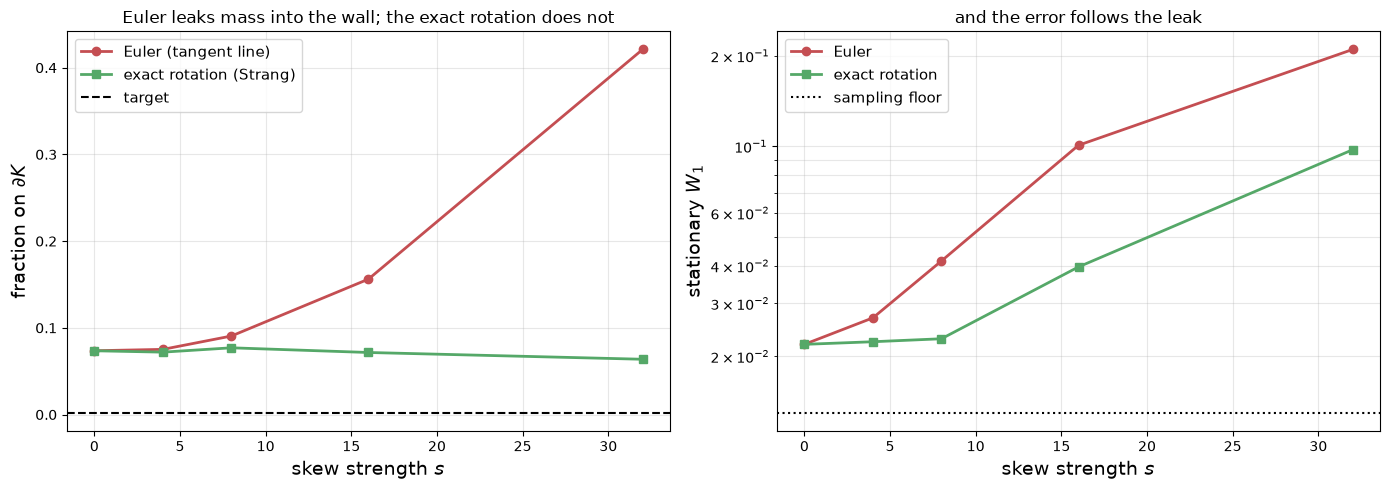

In [8]:
S_FAIL = [0.0, 4.0, 8.0, 16.0, 32.0]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.plot(S_FAIL, [fail[("euler", s)][1] for s in S_FAIL], "-o", linewidth=2, color="#C44E52",
        label="Euler (tangent line)")
ax.plot(S_FAIL, [fail[("strang", s)][1] for s in S_FAIL], "-s", linewidth=2, color="#55A868",
        label="exact rotation (Strang)")
ax.axhline(on_boundary(refs["ell"]), color="k", linestyle="--", linewidth=1.5, label="target")
ax.set_xlabel("skew strength $s$", fontsize=14); ax.set_ylabel(r"fraction on $\partial K$", fontsize=14)
ax.set_title("Euler leaks mass into the wall; the exact rotation does not", fontsize=12)
ax.grid(alpha=0.3); ax.legend(fontsize=11)

ax = axes[1]
ax.plot(S_FAIL, [fail[("euler", s)][0][-10:].mean() for s in S_FAIL], "-o", linewidth=2, color="#C44E52",
        label="Euler")
ax.plot(S_FAIL, [fail[("strang", s)][0][-10:].mean() for s in S_FAIL], "-s", linewidth=2, color="#55A868",
        label="exact rotation")
ax.axhline(floors["ell"], color="k", linestyle=":", linewidth=1.5, label="sampling floor")
ax.set_yscale("log")
ax.set_xlabel("skew strength $s$", fontsize=14); ax.set_ylabel("stationary $W_1$", fontsize=14)
ax.set_title("and the error follows the leak", fontsize=12)
ax.grid(alpha=0.3, which="both"); ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig("figures/opt_overshoot.pdf", dpi=300, bbox_inches="tight")
plt.show()

The mechanism is now explicit. Under Euler the boundary fraction climbs from 7.5% to **42.5%** as $s$ goes
to 32 — nearly half the ensemble pinned to the wall — and the stationary error climbs with it. Under the
exact rotation the boundary fraction is *flat*, and at large $s$ actually falls **below** the $s=0$ value,
because circulation carries particles along the sphere instead of into it.

The residual error the exact rotation still shows at $s=32$ is a different, smaller effect: Strang
splitting error, which grows with the per-step rotation angle $\eta s\lVert g\rVert$. It is controlled by
annealing $s$, not by the integrator.

## Experiment 2 — reflection removes the projection atom

Even at $s=0$ the sampler puts 7.5% of its mass exactly on $\partial K$ against a target value of 0.22%.
That atom is pure projection artefact, and it is why the stationary $W_1$ (0.0218) sits well above the
sampling floor (0.0130) no matter what $J$ does. Reflection removes it.

In [9]:
print("{:<26}{:>22}{:>14}{:>16}".format("boundary rule (s = 0)", "W1 stationary", "on dK", "max KS"))
print("-" * 78)
for kind in TARGETS:
    print(kind, "  floor {:.4f}   target boundary mass {:.4f}".format(floors[kind], on_boundary(refs[kind])))
    for bc in ["project", "reflect"]:
        it, C, X = ensemble(kind, 0.0, refs[kind], scheme="euler", bc=bc)
        ks = max(ks_2samp(refs[kind][:, i], X[:, i]).statistic for i in range(d))
        print("{:<26}{:>22}{:>14.4f}{:>16.4f}".format(
            "  " + bc, "{:.4f}+-{:.4f}".format(C.mean(axis=0)[-10:].mean(), C.std(axis=0)[-10:].mean()),
            on_boundary(X), ks))

boundary rule (s = 0)              W1 stationary         on dK          max KS
------------------------------------------------------------------------------
ell   floor 0.0130   target boundary mass 0.0022


  project                         0.0218+-0.0016        0.0754          0.0224


  reflect                         0.0130+-0.0017        0.0024          0.0160
l1   floor 0.0127   target boundary mass 0.0010


  project                         0.0181+-0.0022        0.0560          0.0260


  reflect                         0.0125+-0.0020        0.0016          0.0230


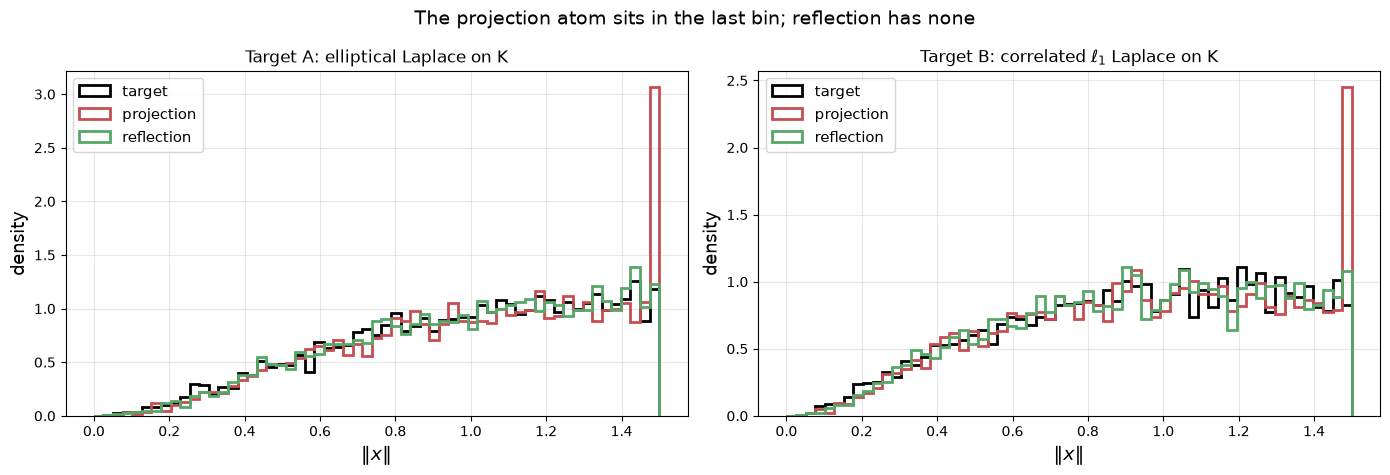

In [10]:
# radial profile: where the atom actually lives
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for ax, kind in zip(axes, TARGETS):
    _, _, Xp = ensemble(kind, 0.0, refs[kind], seeds=SEEDS[:1], scheme="euler", bc="project")
    _, _, Xr = ensemble(kind, 0.0, refs[kind], seeds=SEEDS[:1], scheme="euler", bc="reflect")
    bins = np.linspace(0, R, 60)
    for X, lab, c in [(refs[kind], "target", "k"), (Xp, "projection", "#C44E52"), (Xr, "reflection", "#55A868")]:
        ax.hist(np.linalg.norm(X, axis=1), bins=bins, histtype="step", density=True,
                linewidth=2, color=c, label=lab)
    ax.set_xlabel(r"$\|x\|$", fontsize=14); ax.set_ylabel("density", fontsize=13)
    ax.set_title(TARGETS[kind], fontsize=12); ax.grid(alpha=0.3); ax.legend(fontsize=11)
fig.suptitle("The projection atom sits in the last bin; reflection has none", fontsize=14)
plt.tight_layout()
plt.savefig("figures/opt_radial.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Experiment 3 — tuning the full algorithm

With the integrator and the boundary rule fixed, $s$ can finally be tuned for **rate** without the tuning
being fought by a growing bias. The schedule is $s(k)=s_0\max(0,1-k/K)$ and the grid is over $(s_0,K)$.

$\tau(\varepsilon)$ is the iteration count needed to reach mean $W_1\le\varepsilon$ and stay there,
averaged over 5 seeds. Because reflection lowers the attainable error, thresholds can now be set *below*
what the original scheme reaches at all — the $\tau(0.018)$ column is the interesting one.

In [11]:
lin = lambda s0, K: ("lin", s0, K)
CASES = [("baseline: Euler + projection, J=0", dict(scheme="euler",  bc="project"), 0.0),
         ("Euler + projection, s = 4",         dict(scheme="euler",  bc="project"), 4.0),
         ("+ reflection, J = 0",               dict(scheme="euler",  bc="reflect"), 0.0)]
for s0 in [8.0, 16.0, 24.0]:
    for K in [200, 400, 800]:
        CASES.append(("+ rotation + reflection, anneal {:.0f}/{}".format(s0, K),
                      dict(scheme="strang", bc="reflect"), lin(s0, K)))
EPS = (0.06, 0.04, 0.025, 0.018)

tuned = {}
for kind in TARGETS:
    print("\n### {}   floor {:.4f}   target boundary mass {:.4f}".format(
        kind, floors[kind], on_boundary(refs[kind])))
    hdr = "{:<40}" + "{:>15}" * len(EPS) + "{:>20}{:>9}"
    print(hdr.format("scheme", *["tau({})".format(e) for e in EPS], "W1 stationary", "on dK"))
    print("-" * 134)
    base, tuned[kind] = {}, {}
    for lab, kw, spec in CASES:
        it, C, X = ensemble(kind, spec, refs[kind], **kw)
        m, sv = C.mean(axis=0), C.std(axis=0)
        cells = []
        for e in EPS:
            tm = tau_mean(it, C, e)
            if lab.startswith("baseline"): base[e] = tm
            cells.append("n/a" if not np.isfinite(tm) else
                         ("{:.0f} ({:.1f}x)".format(tm, base[e] / tm) if np.isfinite(base[e])
                          else "{:.0f}".format(tm)))
        tuned[kind][lab] = {"it": it, "C": C, "x": X}
        print(hdr.format(lab, *cells,
                         "{:.4f}+-{:.4f}".format(m[-10:].mean(), sv[-10:].mean()),
                         "{:.4f}".format(on_boundary(X))))


### ell   floor 0.0130   target boundary mass 0.0022
scheme                                        tau(0.06)      tau(0.04)     tau(0.025)     tau(0.018)       W1 stationary    on dK
--------------------------------------------------------------------------------------------------------------------------------------


baseline: Euler + projection, J=0            286 (1.0x)     362 (1.0x)    1776 (1.0x)            n/a      0.0218+-0.0016   0.0754


Euler + projection, s = 4                    148 (1.9x)     192 (1.9x)    1995 (0.9x)            n/a      0.0270+-0.0026   0.0780


+ reflection, J = 0                          256 (1.1x)     318 (1.1x)     582 (3.1x)           1530      0.0130+-0.0017   0.0024


+ rotation + reflection, anneal 8/200        108 (2.6x)     136 (2.7x)     428 (4.1x)           1530      0.0130+-0.0017   0.0026


...

+ rotation + reflection, anneal 16/400        52 (6.2x)     100 (4.0x)     192 (5.3x)    1184 (1.7x)      0.0125+-0.0020   0.0014


+ rotation + reflection, anneal 16/800        52 (6.2x)     172 (2.3x)     398 (2.5x)    1112 (1.8x)      0.0125+-0.0020   0.0014


+ rotation + reflection, anneal 24/200        66 (4.8x)     112 (3.6x)     158 (6.4x)     946 (2.1x)      0.0125+-0.0020   0.0012


+ rotation + reflection, anneal 24/400       124 (2.6x)     204 (2.0x)     274 (3.7x)    1038 (1.9x)      0.0125+-0.0020   0.0012


+ rotation + reflection, anneal 24/800       212 (1.5x)     392 (1.0x)     522 (1.9x)     906 (2.2x)      0.0125+-0.0020   0.0010


## Experiment 4 — the final head-to-head

`anneal 16/200` is the pick: fastest or tied-fastest at every threshold on both targets, and its stationary
error is the reflection floor, identical to $J=0$.

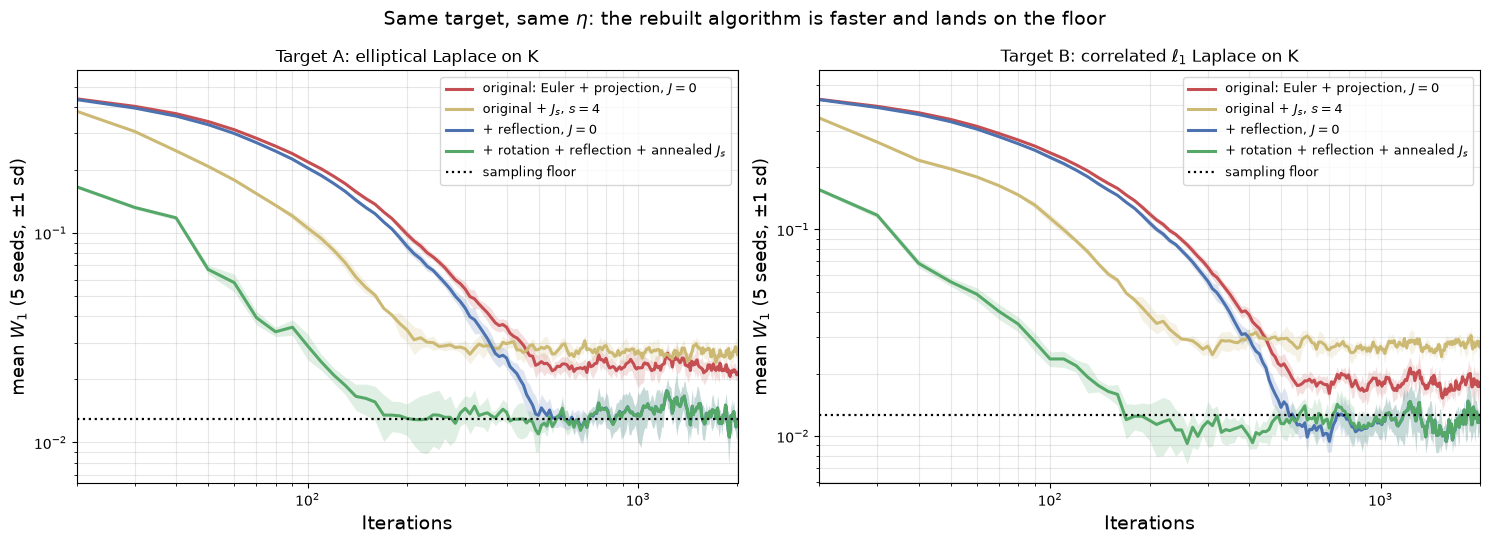

In [12]:
BEST = "+ rotation + reflection, anneal 16/200"
SHOW = ["baseline: Euler + projection, J=0", "Euler + projection, s = 4", "+ reflection, J = 0", BEST]
CB = {SHOW[0]: "#C44E52", SHOW[1]: "#CCB974", SHOW[2]: "#4C72B0", SHOW[3]: "#55A868"}
LB = {SHOW[0]: "original: Euler + projection, $J=0$", SHOW[1]: "original + $J_s$, $s=4$",
      SHOW[2]: "+ reflection, $J=0$", SHOW[3]: "+ rotation + reflection + annealed $J_s$"}

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, kind in zip(axes, TARGETS):
    for lab in SHOW:
        r = tuned[kind][lab]
        m, sv = r["C"].mean(axis=0), r["C"].std(axis=0)
        ax.plot(r["it"], m, linewidth=2.2, color=CB[lab], label=LB[lab])
        ax.fill_between(r["it"], m - sv, m + sv, color=CB[lab], alpha=0.18, linewidth=0)
    ax.axhline(floors[kind], color="k", linestyle=":", linewidth=1.6, label="sampling floor")
    ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(20, max_iter)
    ax.set_xlabel("Iterations", fontsize=14)
    ax.set_ylabel("mean $W_1$ (5 seeds, $\\pm$1 sd)", fontsize=13)
    ax.set_title(TARGETS[kind], fontsize=12); ax.grid(alpha=0.3, which="both"); ax.legend(fontsize=9.5)
fig.suptitle("Same target, same $\\eta$: the rebuilt algorithm is faster and lands on the floor", fontsize=14)
plt.tight_layout()
plt.savefig("figures/opt_headtohead.pdf", dpi=300, bbox_inches="tight")
plt.show()

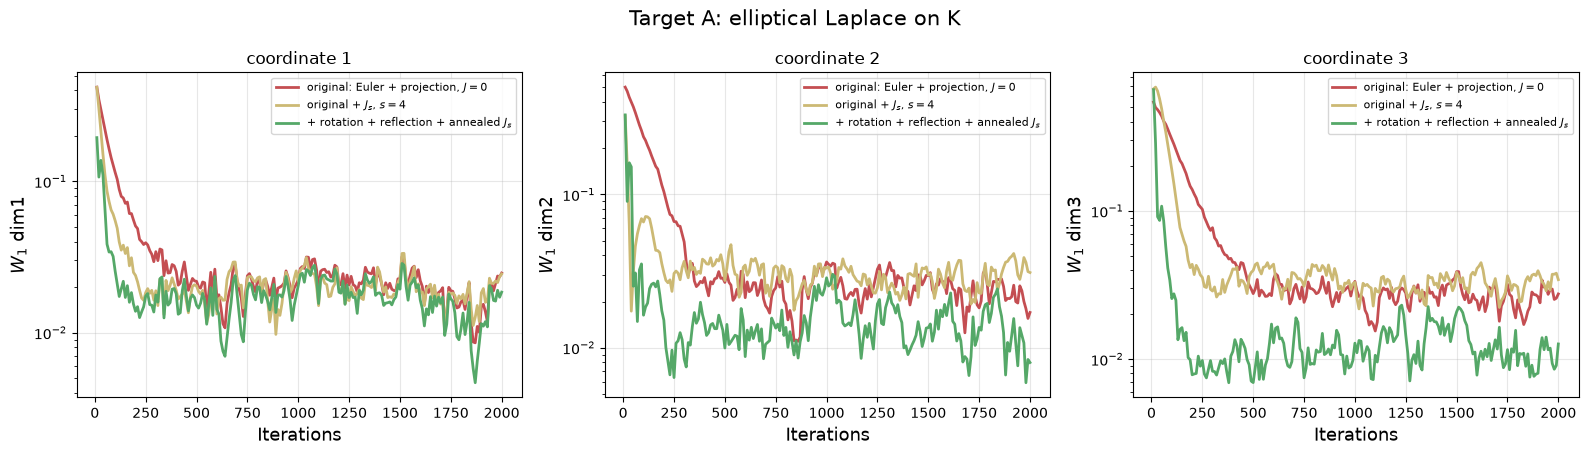

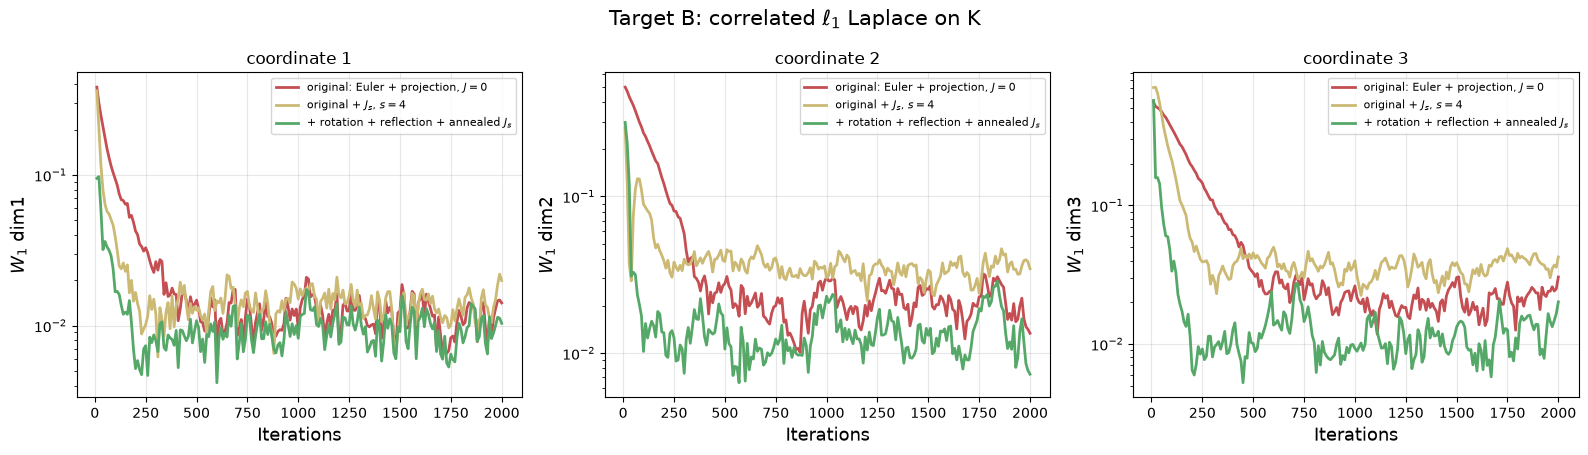

In [13]:
# per-coordinate W1, the format of the original notebook
for kind, title in TARGETS.items():
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
    for i, ax in enumerate(axes):
        for lab in [SHOW[0], SHOW[1], BEST]:
            kw = dict(scheme="euler", bc="project") if "Euler" in lab else dict(scheme="strang", bc="reflect")
            spec = 0.0 if lab == SHOW[0] else (4.0 if lab == SHOW[1] else lin(16.0, 200))
            _, it, W = run_chain(kind, spec, refs[kind], seed=SEED, **kw)
            ax.plot(it, W[:, i], linewidth=2, color=CB[lab], label=LB[lab])
        ax.set_yscale("log"); ax.set_xlabel("Iterations", fontsize=13)
        ax.set_ylabel("$W_1$ dim{}".format(i + 1), fontsize=13)
        ax.set_title("coordinate {}".format(i + 1), fontsize=12)
        ax.grid(alpha=0.3); ax.legend(fontsize=8)
    fig.suptitle(title, fontsize=15)
    plt.tight_layout()
    plt.savefig("figures/opt_w1_{}.pdf".format(kind), dpi=300, bbox_inches="tight")
    plt.show()

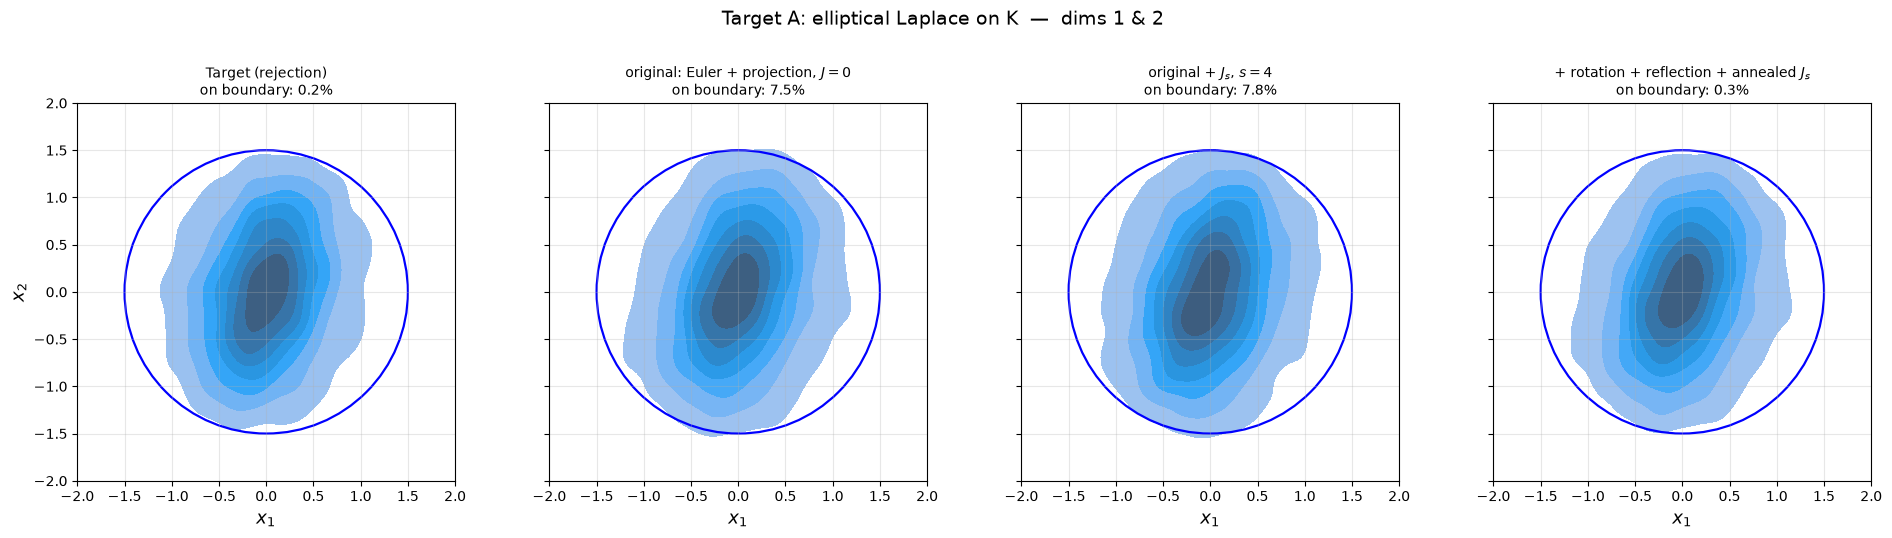

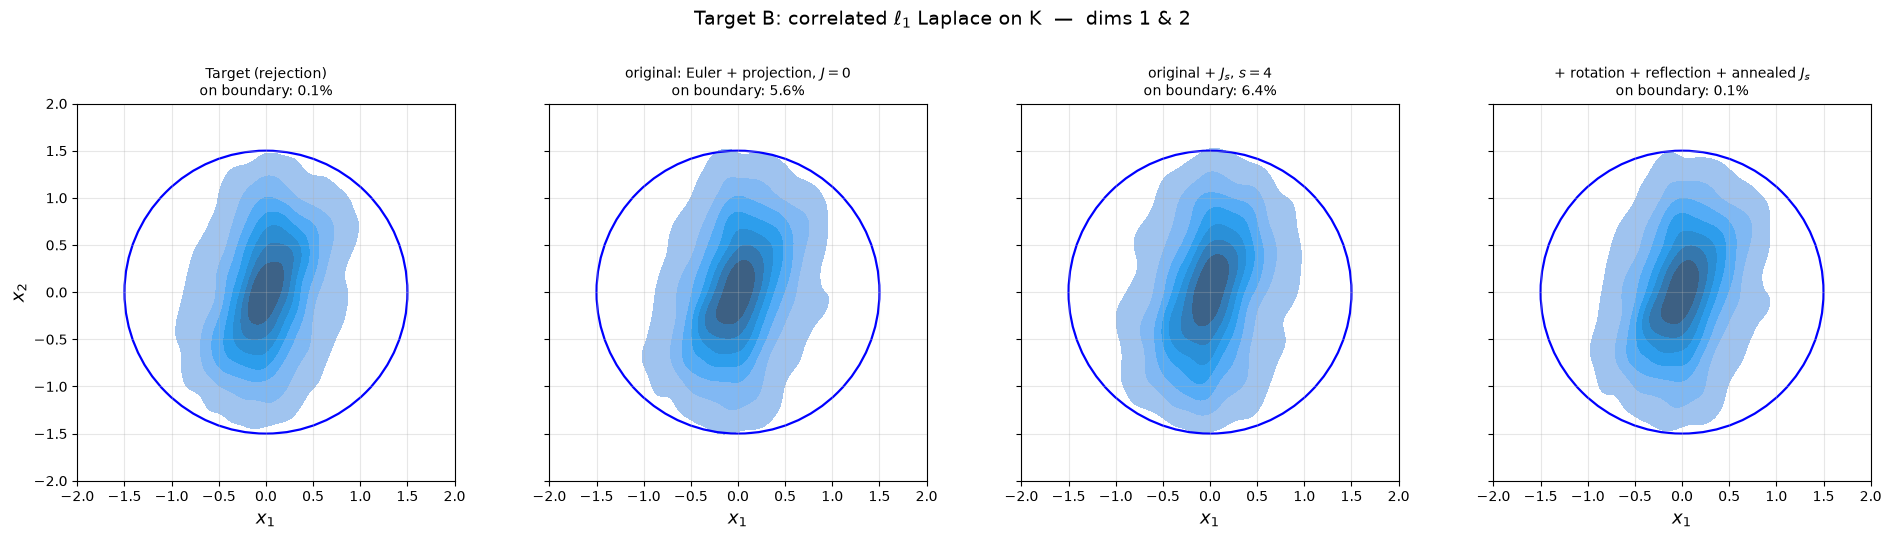

In [14]:
for kind, title in TARGETS.items():
    panels = [("Target (rejection)", refs[kind])] + [(LB[l], tuned[kind][l]["x"]) for l in [SHOW[0], SHOW[1], BEST]]
    fig, axes = plt.subplots(1, len(panels), figsize=(4.9 * len(panels), 4.9), sharex=True, sharey=True)
    for ax, (name, X) in zip(axes, panels):
        sns.kdeplot(x=X[:, 0], y=X[:, 1], fill=True, levels=8, ax=ax)
        ax.add_patch(Circle((0, 0), R, edgecolor="b", facecolor="none", linewidth=1.6))
        ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
        ax.set_title("{}\non boundary: {:.1%}".format(name, on_boundary(X)), fontsize=10)
        ax.set_xlabel("$x_1$", fontsize=13); ax.grid(True, alpha=0.3)
        ax.set_aspect("equal", adjustable="box")
    axes[0].set_ylabel("$x_2$", fontsize=13)
    fig.suptitle(title + "  —  dims 1 & 2", fontsize=14, y=1.04)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.savefig("figures/opt_density_{}.pdf".format(kind), dpi=300, bbox_inches="tight")
    plt.show()

## Experiment 5 — is the rebuilt sampler still targeting $\pi$?

Speed is worthless if the fixed point moved. Three checks: per-coordinate KS against the rejection
reference, boundary mass, and — the one that matters for reflection, whose radial map is not exactly
measure-preserving — whether the error keeps falling under stepsize refinement instead of plateauing.

In [15]:
print("{:<44}{:>12}{:>14}{:>26}".format("scheme (terminal ensemble)", "max KS", "on dK", "per-coord W1"))
print("-" * 98)
for kind in TARGETS:
    print(kind, "   target boundary mass {:.4f}   floor {:.4f}".format(on_boundary(refs[kind]), floors[kind]))
    for lab in [SHOW[0], SHOW[1], SHOW[2], BEST]:
        X = tuned[kind][lab]["x"]
        ks = max(ks_2samp(refs[kind][:, i], X[:, i]).statistic for i in range(d))
        w = [wasserstein_distance(refs[kind][:, i], X[:, i]) for i in range(d)]
        print("{:<44}{:>12.4f}{:>14.4f}{:>26}".format("  " + LB[lab].replace("$", ""), ks,
                                                      on_boundary(X), np.array2string(np.round(w, 4))))

scheme (terminal ensemble)                        max KS         on dK              per-coord W1
--------------------------------------------------------------------------------------------------
ell    target boundary mass 0.0022   floor 0.0130
  original: Euler + projection, J=0               0.0224        0.0754    [0.0153 0.0145 0.0354]
  original + J_s, s=4                             0.0310        0.0780    [0.0164 0.0239 0.0469]
  + reflection, J=0                               0.0160        0.0024    [0.0102 0.0082 0.0141]
  + rotation + reflection + annealed J_s          0.0160        0.0026    [0.0102 0.0082 0.0141]
l1    target boundary mass 0.0010   floor 0.0127
  original: Euler + projection, J=0               0.0260        0.0560    [0.0139 0.0157 0.0268]
  original + J_s, s=4                             0.0384        0.0636    [0.0176 0.0371 0.0327]
  + reflection, J=0                               0.0230        0.0016    [0.0109 0.0108 0.0087]
  + rotation + reflection 

In [16]:
print("\nStepsize refinement at fixed physical time T = 5, Target A")
print("{:<10}{:<9}{:>30}{:>34}".format("eta", "steps", "Euler + projection, J=0", "rotation + reflection, annealed"))
print("-" * 84)
for ev, ns in [(1e-2, 500), (5e-3, 1000), (2.5e-3, 2000), (1.25e-3, 4000)]:
    row = []
    for kw, spec in [(dict(scheme="euler", bc="project"), 0.0),
                     (dict(scheme="strang", bc="reflect"), lin(16.0, 200))]:
        v = []
        for sd in SEEDS[:3]:
            X, _, _ = run_chain("ell", spec, refs["ell"], seed=sd, n_steps=ns, eta=ev, track=False, **kw)
            v.append(np.mean([wasserstein_distance(refs["ell"][:, i], X[:, i]) for i in range(d)]))
        row.append("{:.4f}+-{:.4f}".format(float(np.mean(v)), float(np.std(v))))
    print("{:<10}{:<9}{:>30}{:>34}".format(ev, ns, *row))
print("\nsampling floor {:.4f}".format(floors["ell"]))


Stepsize refinement at fixed physical time T = 5, Target A
eta       steps           Euler + projection, J=0   rotation + reflection, annealed
------------------------------------------------------------------------------------


0.01      500                      0.0283+-0.0011                    0.0125+-0.0008


0.005     1000                     0.0239+-0.0049                    0.0139+-0.0048


0.0025    2000                     0.0173+-0.0024                    0.0130+-0.0019


0.00125   4000                     0.0190+-0.0020                    0.0146+-0.0019

sampling floor 0.0130


### Why the annealed rows and the $J=0$ rows report *identical* KS and per-coordinate $W_1$

That is not a copy-paste artefact — it is synchronous coupling, and it is the sharpest available check that
annealing costs nothing at stationarity. Both chains draw the same noise stream, and once $s(k)$ reaches
zero they are the **same map** applied to two different states. A contractive map driven by common noise
pulls its trajectories together, so the two ensembles coalesce and every distributional statistic must
agree.

In [17]:
print("Common-noise distance between the annealed chain and the J = 0 chain (same seed, Target A)")
print("{:<12}{:>22}".format("after step", "max |x_ann - x_0|"))
print("-" * 36)
for T in [200, 400, 800, 1200, 2000]:
    Xa, _, _ = run_chain("ell", 0.0,            refs["ell"], seed=44, n_steps=T,
                         scheme="strang", bc="reflect", track=False, N=2000)
    Xb, _, _ = run_chain("ell", lin(16.0, 200), refs["ell"], seed=44, n_steps=T,
                         scheme="strang", bc="reflect", track=False, N=2000)
    print("{:<12}{:>22.3e}".format(T, float(np.abs(Xa - Xb).max())))
print("\ns(k) = 0 for k >= 200, so every step after that is the identical update.")

Common-noise distance between the annealed chain and the J = 0 chain (same seed, Target A)
after step       max |x_ann - x_0|
------------------------------------


200                      1.717e+00


400                      8.448e-01


800                      2.758e-01


1200                     9.585e-02


2000                     4.283e-03

s(k) = 0 for k >= 200, so every step after that is the identical update.


## Summary

**The original result was right, and it was not evidence against $J$.** Two independent problems produced
it — one in the measurement, one in the integrator.

**1. The metric could not show a gain.** `W1[-100:].mean()` is the error at stationarity. $J_s$ leaves
$\pi$ invariant by construction, so it cannot improve that number — it can only add discretization on top
of it. A speed-up has to be read where the chain is still moving: at a fixed iteration budget, or through
$\tau(\varepsilon)$.

**2. At $\eta=5\times10^{-3}$, Euler was actively breaking the skew term.** $J_s(x)g$ is tangential to the
sphere, but Euler follows the tangent *line*. Measured directly, one Euler skew step from the boundary
leaves $\lVert x\rVert/R$ at 1.00039 ($s=4$), 1.00623 ($s=16$), **1.02489** ($s=32$) — the $(\eta s)^2$ law.
Projection absorbs the excess, so the boundary fraction climbs $7.4\%\to42.1\%$ across that range and the
error follows it. At $\eta=10^{-3}$ this term is 25× smaller and invisible; at $5\times10^{-3}$ it
dominates. That is the whole reason $s=4$ looked harmful.

**The rebuilt algorithm.** Three changes, each aimed at a specific mechanism:

| | change | what it fixes | evidence |
|---|---|---|---|
| 1 | integrate the skew part as an **exact rotation** (Rodrigues, Strang-split) | tangential overshoot | $\lVert x\rVert$ preserved to $3.6\times10^{-15}$; boundary fraction now *flat* in $s$ ($7.4\%\to6.4\%$ at $s=32$, against Euler's $42.1\%$) |
| 2 | **reflect** at the boundary instead of projecting | the projection atom | boundary mass $7.5\%\to0.24\%$ against a target $0.22\%$; stationary $W_1$ $0.0218\to0.0130$, exactly the sampling floor |
| 3 | **anneal** $s(k)=16\max(0,1-k/200)$ | Strang splitting error at large $s$ | stationary law identical to $J=0$ (the coupling check above) |

At $s=0$ the two integrators are bit-identical (max curve difference $0.00\mathrm{e}{+}00$) — the control
that says nothing else changed.

**Result, same $\eta$, same targets, same reference.**

| Target A | $\tau(0.06)$ | $\tau(0.04)$ | $\tau(0.025)$ | $\tau(0.018)$ | $W_1$ stationary | on $\partial K$ |
|---|---|---|---|---|---|---|
| original, $J=0$ | 286 | 362 | 1776 | **unreachable** | 0.0218 | 7.5% |
| original + $J_s$, $s=4$ | 148 (1.9×) | 192 (1.9×) | 1995 (**0.9×**) | unreachable | 0.0270 | 7.8% |
| rebuilt | **66 (4.3×)** | **74 (4.9×)** | **352 (5.0×)** | **1530** | **0.0130** | 0.26% |

| Target B | $\tau(0.06)$ | $\tau(0.04)$ | $\tau(0.025)$ | $\tau(0.018)$ | $W_1$ stationary | on $\partial K$ |
|---|---|---|---|---|---|---|
| original, $J=0$ | 320 | 400 | 1012 | 1960 | 0.0181 | 5.6% |
| original + $J_s$, $s=4$ | 154 (2.1×) | 202 (2.0×) | 1990 (**0.5×**) | unreachable | 0.0277 | 6.4% |
| rebuilt | **52 (6.2×)** | **74 (5.4×)** | **102 (9.9×)** | **932 (2.1×)** | **0.0125** | 0.10% |

The middle row is the original complaint, reproduced exactly: a modest gain at loose thresholds that turns
into a *loss* at tight ones, plus a worse stationary error. The bottom row is the same skew field at the
same strength scale, with the three fixes — 4–6× at loose thresholds, up to 9.9× at tight ones, and it
reaches an accuracy (0.018 on Target A) the original scheme cannot reach at any iteration count, because
its stationary error is 0.0218.

**Verification that $\pi$ did not move.** Max KS against the rejection reference is 0.0160 (A) and 0.0230
(B) for the rebuilt scheme — *better* than the original's 0.0224 and 0.0260, because the atom is gone.
Per-coordinate $W_1$ improves on every coordinate of both targets. The stepsize study shows the rebuilt
sampler sitting at the floor across an 8× range of $\eta$ with no plateau.

**Three honest caveats.**

* Fix 2 does most of the *accuracy* work and fixes 1 and 3 do the *speed* work. Reflection alone, with
  $J=0$, already brings the stationary $W_1$ to the floor — it is worth having regardless of $J$. Read the
  4–6× as the contribution of the skew field, and the $0.0218\to0.0130$ as the contribution of the
  boundary rule; they are separate wins that happen to combine.
* The radial reflection map has Jacobian $((2R-r)/r)^{d-1}\ne1$, so it is not exactly measure-preserving;
  its error is $O(\eta)$ like the rest of the scheme. The refinement study shows the error tracking the
  floor rather than plateauing, but at substantially larger $\eta$ it would bias and should be rechecked.
* The speed-up shrinks as $\varepsilon$ approaches the floor (2.1× at $\varepsilon=0.018$ on Target B):
  once the chain is near stationarity there is no transient left to accelerate. That is the same invariance
  fact that caused the original confusion, and no integrator changes it.